## **Smart Gadget Recognition System -> EfficientNetB0**

In [1]:
from IPython.display import HTML
HTML("""
<h3>Training a Custom Model from Scratch</h3>
<table border="1" style="border-collapse:collapse; font-size:14px; width:60%">
  <tr style="background:#f2f2f2; font-weight:bold;">
    <td style="padding:8px 20px;">Base model</td>
    <td style="padding:8px 20px;">resolution</td>
  </tr>
  <tr><td style="padding:8px 20px;">EfficientNetB0</td><td style="padding:8px 20px;">224</td></tr>
  <tr><td style="padding:8px 20px;">EfficientNetB1</td><td style="padding:8px 20px;">240</td></tr>
  <tr><td style="padding:8px 20px;">EfficientNetB2</td><td style="padding:8px 20px;">260</td></tr>
  <tr><td style="padding:8px 20px;">EfficientNetB3</td><td style="padding:8px 20px;">300</td></tr>
  <tr><td style="padding:8px 20px;">EfficientNetB4</td><td style="padding:8px 20px;">380</td></tr>
  <tr><td style="padding:8px 20px;">EfficientNetB5</td><td style="padding:8px 20px;">456</td></tr>
  <tr><td style="padding:8px 20px;">EfficientNetB6</td><td style="padding:8px 20px;">528</td></tr>
  <tr><td style="padding:8px 20px;">EfficientNetB7</td><td style="padding:8px 20px;">600</td></tr>
</table>
""")

Base model,resolution
EfficientNetB0,224
EfficientNetB1,240
EfficientNetB2,260
EfficientNetB3,300
EfficientNetB4,380
EfficientNetB5,456
EfficientNetB6,528
EfficientNetB7,600


### Data Pre Processing

In [4]:
import numpy as np
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [5]:
os.getcwd()

'C:\\Users\\pmgho'

In [7]:
os.chdir('C:\\Users\\pmgho\\OneDrive\\Desktop\\EfficientNet_Project_By_Prajwal')
os.getcwd()

'C:\\Users\\pmgho\\OneDrive\\Desktop\\EfficientNet_Project_By_Prajwal'

In [8]:
dataset_path = os.listdir('dataset')

print (dataset_path)  # what kinds of classes are in this dataset

print("Types of classes labels found: ", len(dataset_path))

['earphones', 'headphones', 'phones']
Types of classes labels found:  3


In [10]:
class_labels = []

for item in dataset_path:
 # Get all the file names
 all_classes = os.listdir('dataset' + '/' +item)
 #print(all_classes)

 # Add them to the list
 for room in all_classes:
    class_labels.append((item, str('dataset_path' + '/' +item) + '/' + room))

### **Build a dataframe**

In [11]:
df = pd.DataFrame(data=class_labels, columns=['Labels', 'image'])
print(df.head())
print(df.tail())

      Labels                                        image
0  earphones   dataset_path/earphones/earphones_00000.jpg
1  earphones   dataset_path/earphones/earphones_00001.jpg
2  earphones   dataset_path/earphones/earphones_00002.jpg
3  earphones  dataset_path/earphones/earphones_00003.jpeg
4  earphones  dataset_path/earphones/earphones_00004.jpeg
     Labels                                 image
429  phones  dataset_path/phones/phones_00143.jpg
430  phones  dataset_path/phones/phones_00144.jpg
431  phones  dataset_path/phones/phones_00145.jpg
432  phones  dataset_path/phones/phones_00146.jpg
433  phones  dataset_path/phones/phones_00147.jpg


## **Let's check how many samples for each category are present**

In [12]:
print("Total number of images in the dataset: ", len(df))

label_count = df['Labels'].value_counts()
print(label_count)

Total number of images in the dataset:  434
Labels
phones        148
headphones    147
earphones     139
Name: count, dtype: int64


In [13]:
import cv2
path = 'dataset/'
dataset_path = os.listdir('dataset')

im_size = 224

images = []
labels = []

for i in dataset_path:
    data_path = path + str(i)  
    filenames = [i for i in os.listdir(data_path) ]
   
    for f in filenames:
        img = cv2.imread(data_path + '/' + f)
        img = cv2.resize(img, (im_size, im_size))
        images.append(img)
        labels.append(i)

In [14]:
images = np.array(images)
images = images.astype('float32')   # NO /255 here!

print("Shape:", images.shape)
print("Min:", images.min(), "| Max:", images.max())

Shape: (434, 224, 224, 3)
Min: 0.0 | Max: 255.0


In [15]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
y=df['Labels'].values
print(y)

y_labelencoder = LabelEncoder ()
y = y_labelencoder.fit_transform (y)
print (y)

['earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'earphones' 'earphones'
 'earphones' 'earphones' 'earphones' 'earphones' 'e

In [16]:
y=y.reshape(-1,1)

from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([('my_ohe', OneHotEncoder(), [0])], remainder='passthrough')
Y = ct.fit_transform(y) #.toarray()
print(Y[:5])
print(Y[35:])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [17]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

images, Y = shuffle(images, Y, random_state=1)
train_x, test_x, train_y, test_y = train_test_split(
    images, Y, 
    test_size=0.20,      
    random_state=415
)

train_x, val_x, train_y, val_y = train_test_split(
    train_x, train_y, 
    test_size=0.15,      
    random_state=415
)

print("Train images  :", train_x.shape)
print("Val images    :", val_x.shape)
print("Test images   :", test_x.shape)

Train images  : (294, 224, 224, 3)
Val images    : (53, 224, 224, 3)
Test images   : (87, 224, 224, 3)


## **EfficientNet Implementation**

In [18]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

NUM_CLASSES = 3
IMG_SIZE = 224

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

outputs = EfficientNetB0(
    include_top=False,        
    weights='imagenet',       
    classes=NUM_CLASSES
)(inputs)

x = layers.GlobalAveragePooling2D()(outputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, x)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [21]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf

NUM_CLASSES = 3
IMG_SIZE = 224

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs
)

base_model.trainable = False  

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)   

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

hist = model.fit(
    train_x, train_y,
    validation_data=(val_x, val_y),
    epochs=30,
    verbose=2
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃                ┃              ┃  Param ┃               ┃
┃ Layer (type)   ┃ Output Shape ┃      # ┃ Connected to  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2  │ (None, 224,  │      0 │ -             │
│ (InputLayer)   │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling_2    │ (None, 224,  │      0 │ input_layer_… │
│ (Rescaling)    │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ normalization… │ (None, 224,  │      7 │ rescaling_2[… │
│ (Normalizatio… │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling_3    │ (None, 224,  │      0 │ normalizatio… │
│ (Rescaling)    │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv_pad  │ (None, 225,  │      0 │ rescaling_3[… │
│ (ZeroPadding2… │ 225, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv      │ (None, 112,  │    864 │ stem_conv_pa… │
│ (Conv2D)       │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_bn        │ (None, 112,  │    128 │ stem_conv[0]… │
│ (BatchNormali… │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_activati… │ (None, 112,  │      0 │ stem_bn[0][0] │
│ (Activation)   │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_dwconv │ (None, 112,  │    288 │ stem_activat… │
│ (DepthwiseCon… │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_bn     │ (None, 112,  │    128 │ block1a_dwco… │
│ (BatchNormali… │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_activ… │ (None, 112,  │      0 │ block1a_bn[0… │
│ (Activation)   │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_sq… │ (None, 32)   │      0 │ block1a_acti… │
│ (GlobalAverag… │              │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │      0 │ block1a_se_s… │
│ (Reshape)      │ 32)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │    264 │ block1a_se_r… │
│ (Conv2D)       │ 8)           │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 1, 1, │    288 │ block1a_se_r… │
│ (Conv2D)       │ 32)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 112,  │      0 │ block1a_acti… │
│ (Multiply)     │ 112, 32)     │        │ block1a_se_e… │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 112,  │    512 │ block1a_se_e… │
│ (Conv2D)       │ 112, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 112,  │     64 │ block1a_proj… │
│ (BatchNormali… │ 112, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_expan… │ (None, 112,  │  1,536 │ block1a_proj… │
│ (Conv2D)       │ 112, 96)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_expan… │ (None, 112,  │    384 │ block2a_expa… │
│ (BatchNormali… │ 112, 96)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_expan… │ (None, 112,  │      0 │ block2a_expa… │
│ (Activation)   │ 112, 96)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_dwcon… │ (None, 113,  │      0 │ bloc

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/30
10/10 - 25s - 3s/step - accuracy: 0.4966 - loss: 1.0435 - val_accuracy: 0.6981 - val_loss: 0.7462
Epoch 2/30
10/10 - 12s - 1s/step - accuracy: 0.7619 - loss: 0.6349 - val_accuracy: 0.7358 - val_loss: 0.6267
Epoch 3/30
10/10 - 11s - 1s/step - accuracy: 0.8299 - loss: 0.4729 - val_accuracy: 0.7925 - val_loss: 0.6068
Epoch 4/30
10/10 - 11s - 1s/step - accuracy: 0.8844 - loss: 0.3806 - val_accuracy: 0.7736 - val_loss: 0.6116
Epoch 5/30
10/10 - 12s - 1s/step - accuracy: 0.8844 - loss: 0.3376 - val_accuracy: 0.7925 - val_loss: 0.5797
Epoch 6/30
10/10 - 11s - 1s/step - accuracy: 0.8946 - loss: 0.3270 - val_accuracy: 0.7925 - val_loss: 0.5740
Epoch 7/30
10/10 - 11s - 1s/step - accuracy: 0.9082 - loss: 0.3003 - val_accuracy: 0.7736 - val_loss: 0.5928
Epoch 8/30
10/10 - 11s - 1s/step - accuracy: 0.8912 - loss: 0.2656 - val_accuracy: 0.7736 - val_loss: 0.5981
Epoch 9/30
10/10 - 13s - 1s/step - accuracy: 0.9014 - loss: 0.2659 - val_accuracy: 0.7736 - val_loss: 0.5851
Epoch 10/30
10/10 -

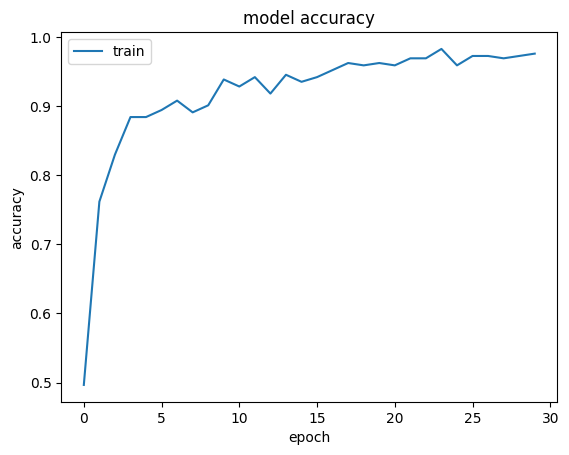

In [23]:
import matplotlib.pyplot as plt
def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()
plot_hist(hist)

In [24]:
preds = model.evaluate(test_x, test_y)
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 940ms/step - accuracy: 0.8966 - loss: 0.3045
Loss = 0.3045095205307007
Test Accuracy = 0.8965517282485962


## **Testing Efficient Model On Unseen data**

In [25]:
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input

Input image shape: (1, 224, 224, 3)


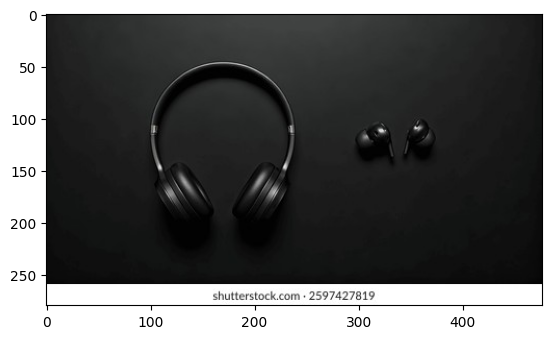

In [32]:
import cv2
import numpy as np

img_path = r'C:\Users\pmgho\OneDrive\Desktop\EfficientNet_Project_By_Prajwal\dataset\headphones\headphones_00000.jpg'

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image not found. Check path or extension!")

img = cv2.resize(img, (224, 224))

x = np.expand_dims(img, axis=0)
print('Input image shape:', x.shape)

my_image = imread(img_path)
imshow(my_image)

In [33]:
preds=model.predict(x)
preds 

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([[7.1108025e-01, 2.8834444e-01, 5.7535537e-04]], dtype=float32)

### **Cuda and cudnn is installed for this tensorflow version. So we can see GPU is enabled**

In [34]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [35]:
%%timeit -n1 -r1 
with tf.device('/CPU:0'):
    cpu_performance =model.fit(train_x, train_y, epochs=30, verbose=2)
    cpu_performance

Epoch 1/30
10/10 - 12s - 1s/step - accuracy: 0.9728 - loss: 0.1028
Epoch 2/30
10/10 - 10s - 966ms/step - accuracy: 0.9796 - loss: 0.1096
Epoch 3/30
10/10 - 9s - 934ms/step - accuracy: 0.9796 - loss: 0.1021
Epoch 4/30
10/10 - 10s - 952ms/step - accuracy: 0.9864 - loss: 0.0985
Epoch 5/30
10/10 - 9s - 937ms/step - accuracy: 0.9694 - loss: 0.1048
Epoch 6/30
10/10 - 9s - 920ms/step - accuracy: 0.9830 - loss: 0.0989
Epoch 7/30
10/10 - 10s - 1s/step - accuracy: 0.9796 - loss: 0.1012
Epoch 8/30
10/10 - 10s - 1s/step - accuracy: 0.9898 - loss: 0.0814
Epoch 9/30
10/10 - 10s - 959ms/step - accuracy: 0.9830 - loss: 0.0959
Epoch 10/30
10/10 - 11s - 1s/step - accuracy: 0.9762 - loss: 0.0989
Epoch 11/30
10/10 - 11s - 1s/step - accuracy: 0.9796 - loss: 0.0825
Epoch 12/30
10/10 - 11s - 1s/step - accuracy: 0.9796 - loss: 0.0842
Epoch 13/30
10/10 - 10s - 964ms/step - accuracy: 0.9796 - loss: 0.0866
Epoch 14/30
10/10 - 10s - 956ms/step - accuracy: 0.9864 - loss: 0.0767
Epoch 15/30
10/10 - 11s - 1s/step - 

In [36]:
%%timeit -n1 -r1 
with tf.device('/GPU:0'):
    gpu_performance =model.fit(train_x, train_y, epochs=30, verbose=2)
    gpu_performance

Epoch 1/30
10/10 - 10s - 956ms/step - accuracy: 0.9898 - loss: 0.0522
Epoch 2/30
10/10 - 10s - 968ms/step - accuracy: 0.9864 - loss: 0.0585
Epoch 3/30
10/10 - 11s - 1s/step - accuracy: 0.9898 - loss: 0.0619
Epoch 4/30
10/10 - 10s - 1s/step - accuracy: 0.9864 - loss: 0.0652
Epoch 5/30
10/10 - 9s - 948ms/step - accuracy: 0.9966 - loss: 0.0489
Epoch 6/30
10/10 - 9s - 945ms/step - accuracy: 0.9932 - loss: 0.0484
Epoch 7/30
10/10 - 10s - 1s/step - accuracy: 0.9932 - loss: 0.0572
Epoch 8/30
10/10 - 10s - 967ms/step - accuracy: 0.9898 - loss: 0.0539
Epoch 9/30
10/10 - 10s - 1s/step - accuracy: 0.9898 - loss: 0.0582
Epoch 10/30
10/10 - 10s - 1s/step - accuracy: 0.9864 - loss: 0.0571
Epoch 11/30
10/10 - 10s - 978ms/step - accuracy: 0.9966 - loss: 0.0448
Epoch 12/30
10/10 - 10s - 978ms/step - accuracy: 0.9898 - loss: 0.0563
Epoch 13/30
10/10 - 10s - 988ms/step - accuracy: 0.9966 - loss: 0.0422
Epoch 14/30
10/10 - 10s - 980ms/step - accuracy: 0.9966 - loss: 0.0439
Epoch 15/30
10/10 - 10s - 1s/ste